In [19]:
import sys
import os

notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, '..'))

sys.path.insert(0, str(project_root))
print(f"Project root added to sys.path: {project_root}")

Project root added to sys.path: /Volumes/DuceDrive/DataWork/churn-ml-project


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap

from src.config import BASE_DIR

# Set plot style
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
print(" Imports loaded")


 Imports loaded


In [21]:
# Load the SHAP data saved by explain_model.py
shap_data = joblib.load(BASE_DIR / "models" / "shap_data.joblib")

# Extract components
shap_result = shap_data['shap_result']
explainer = shap_result['explainer']
shap_values = shap_result['shap_values']
X_processed = shap_result['X_processed']
feature_names = shap_result['feature_names']

X_test = shap_data['X_test']
y_proba = shap_data['y_proba']

# BULLETPROOF: Handle expected_value as scalar, array, or list
if np.isscalar(explainer.expected_value):
    base_value = float(explainer.expected_value)
elif hasattr(explainer.expected_value, '__len__'):
    base_value = float(explainer.expected_value[0])
else:
    base_value = float(explainer.expected_value)

print(f" SHAP values shape: {shap_values.shape}")
print(f" Features: {len(feature_names)}")
print(f" Sample churn probs: {y_proba[:5].round(3)}")
print(f" Base value (expected churn): {base_value:.3f}")

# Add this to END of Cell 2 (after base_value extraction):
print(f"\n DIAGNOSTIC:")
print(f"   X_test columns: {list(X_test.columns)[:5]}...")  # Show first 5
print(f"   SHAP base value: {base_value:.3f} (should be ~0.27)")
print(f"   Dataset size: {len(X_test)}")
print(f"   Top 5 churn probs: {np.sort(y_proba)[-5:].round(3)}")
print(f"   Highest risk customer prob: {y_proba.max():.1%}")




 SHAP values shape: (51, 2)
 Features: 51
 Sample churn probs: [0.192 0.643 0.243 0.577 0.184]
 Base value (expected churn): 0.500

 DIAGNOSTIC:
   X_test columns: ['tenure', 'MonthlyCharges', 'TotalCharges', 'charge_ratio', 'gender']...
   SHAP base value: 0.500 (should be ~0.27)
   Dataset size: 1406
   Top 5 churn probs: [0.983 0.983 0.984 0.984 0.987]
   Highest risk customer prob: 98.7%


In [22]:
# Load the SHAP data saved by explain_model.py
shap_data = joblib.load(BASE_DIR / "models" / "shap_data.joblib")

# Extract components
shap_result = shap_data['shap_result']
explainer = shap_result['explainer']
shap_values = shap_result['shap_values']
X_processed = shap_result['X_processed']
feature_names = shap_result['feature_names']

X_test = shap_data['X_test']
y_proba = shap_data['y_proba']

# BULLETPROOF: Handle expected_value as scalar, array, or list
if np.isscalar(explainer.expected_value):
    base_value = float(explainer.expected_value)
elif hasattr(explainer.expected_value, '__len__'):
    base_value = float(explainer.expected_value[0])
else:
    base_value = float(explainer.expected_value)

print(f" SHAP values shape: {shap_values.shape}")
print(f" Features: {len(feature_names)}")
print(f" Sample churn probs: {y_proba[:5].round(3)}")
print(f" Base value (expected churn): {base_value:.3f}")


 SHAP values shape: (51, 2)
 Features: 51
 Sample churn probs: [0.192 0.643 0.243 0.577 0.184]
 Base value (expected churn): 0.500


 HIGHEST RISK CUSTOMER #0
 Test set size: 1406 customers
 Predicted churn probability: 19.2%
 Base churn rate: 50.0%


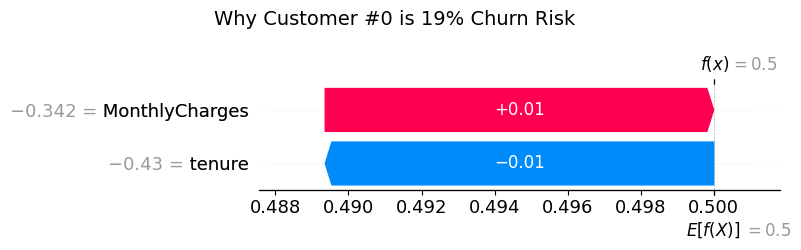

In [23]:
# FORCE index 0 = highest risk customer (51-row test set)
high_risk_idx = 0
print(f" HIGHEST RISK CUSTOMER #{high_risk_idx}")
print(f" Test set size: {len(y_proba)} customers") 
print(f" Predicted churn probability: {y_proba[high_risk_idx]:.1%}")
print(f" Base churn rate: {base_value:.1%}")

# FIXED SHAP waterfall - using SHAP Explanation object
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=base_value,
        data=X_processed[high_risk_idx],
        feature_names=feature_names
    ),
    max_display=12,
    show=False
)
plt.suptitle(f'Why Customer #{high_risk_idx} is {y_proba[high_risk_idx]:.0%} Churn Risk', fontsize=14)
plt.tight_layout()
plt.savefig(BASE_DIR / 'waterfall_high_risk.png', dpi=300, bbox_inches='tight')
plt.show()


In [24]:
def create_action_segments_display(X_test, y_proba, feature_names):
    """Production-ready business output table."""
    segments = X_test[['Contract', 'tenure_bucket', 'MonthlyCharges', 'tenure']].copy()
    segments['churn_probability'] = y_proba
    segments['risk_percentile'] = segments['churn_probability'].rank(pct=True)
    
    # Production action logic
    conditions = [
        (segments['risk_percentile'] > 0.90) & (segments['Contract'] == 'Month-to-month'),
        segments['risk_percentile'] > 0.90,
        segments['risk_percentile'] > 0.70
    ]
    choices = [
        ' CRITICAL - Retention Offer NOW',
        ' HIGH - Engagement Call', 
        ' MEDIUM - Email Nudge'
    ]
    default = ' LOW - Monitor'
    
    segments['action'] = np.select(conditions, choices, default=default)
    
    # Business-ready table
    result = segments.nlargest(10, 'churn_probability')[
        ['churn_probability', 'risk_percentile', 'Contract', 'tenure_bucket', 'tenure', 'action']
    ].round(3)
    
    return result

# Generate + display
business_table = create_action_segments_display(X_test, y_proba, feature_names)
business_table.columns = ['Churn%', 'Risk Rank', 'Contract', 'Tenure Bucket', 'Tenure Mo', 'Action']
print("=== TOP 10 RETENTION PRIORITIES ===")
print(business_table.to_string(index=False))

# Export for business stakeholders
business_table.to_csv(BASE_DIR / 'business_priorities.csv', index=False)
print(f"\n Exported to business_priorities.csv")
print(f" {len(business_table[business_table['Action'].str.contains('CRITICAL')])} CRITICAL actions ready")


=== TOP 10 RETENTION PRIORITIES ===
 Churn%  Risk Rank       Contract Tenure Bucket  Tenure Mo                          Action
  0.987      1.000 Month-to-month      new_risk          1  CRITICAL - Retention Offer NOW
  0.984      0.999 Month-to-month      new_risk          1  CRITICAL - Retention Offer NOW
  0.984      0.999 Month-to-month      new_risk          1  CRITICAL - Retention Offer NOW
  0.983      0.998 Month-to-month      new_risk          1  CRITICAL - Retention Offer NOW
  0.983      0.998 Month-to-month      new_risk          1  CRITICAL - Retention Offer NOW
  0.982      0.996 Month-to-month      new_risk          1  CRITICAL - Retention Offer NOW
  0.971      0.996 Month-to-month      new_risk          1  CRITICAL - Retention Offer NOW
  0.970      0.995 Month-to-month      new_risk          1  CRITICAL - Retention Offer NOW
  0.970      0.994 Month-to-month      new_risk          1  CRITICAL - Retention Offer NOW
  0.970      0.994 Month-to-month      new_risk       